# 01 · Elegir la herramienta correcta

**Qué pregunta responde este cuaderno.** ¿Qué sabe hacer cada una de las cuatro herramientas del agente y cuánto cuesta usarla?

El agente no lee el informe entero: pide trozos. Tiene cuatro formas de pedirlos y se diferencian muchísimo en precisión y en cantidad de texto devuelto. Elegir mal no solo sale caro: una cifra leída de un párrafo puede acabar siendo la del ejercicio equivocado.

> **Cifra exacta → XBRL · Explicación → búsqueda · Sección completa → último recurso**

Todo se ejecuta con los datos locales. No interviene ningún modelo de lenguaje y no se gasta nada.

In [1]:
# Arranque reproducible desde la raíz o desde notebooks/
import pathlib, re, subprocess, sys, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from IPython.display import Markdown, display

RAIZ = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "pyproject.toml").is_file())
if str(RAIZ / "src") not in sys.path:
    sys.path.insert(0, str(RAIZ / "src"))

from agente10k import datos
from agente10k.herramientas import (
    get_xbrl_fact, list_available, read_section, search_filings,
)

AZUL, VERDE, NARANJA, ROJO, GRIS = "#2563EB", "#16A34A", "#F59E0B", "#DC2626", "#64748B"
plt.rcParams.update({"figure.dpi": 120, "axes.titleweight": "bold", "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})

## 1. La decisión en diez segundos

La herramienta correcta depende del tipo de pregunta, no de cuál parezca más potente. El diagrama no consulta datos: resume la decisión. Léelo de arriba abajo.

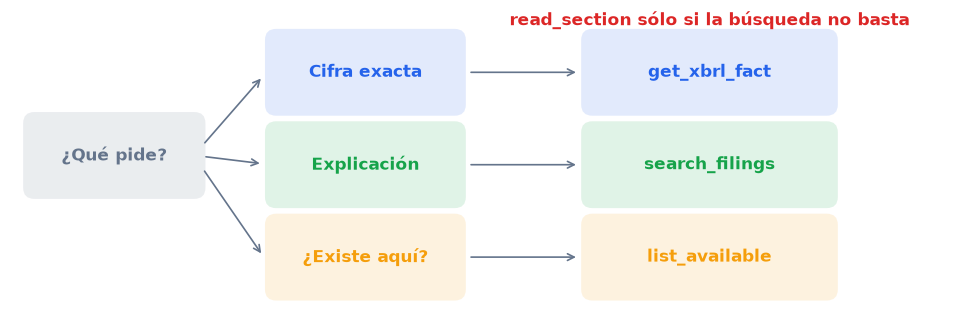

In [2]:
# Visual 1 · Ruta principal de una pregunta
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.set_xlim(0, 10); ax.set_ylim(0, 3.2); ax.axis("off")

def caja(x, y, ancho, texto, color):
    ax.add_patch(FancyBboxPatch((x, y), ancho, .78, boxstyle="round,pad=.08,rounding_size=.12",
                                facecolor=color, edgecolor="none", alpha=.13))
    ax.text(x + ancho/2, y + .39, texto, ha="center", va="center", color=color, weight="bold")

caja(.2, 1.25, 1.8, "¿Qué pide?", GRIS)
caja(2.8, 2.15, 2.0, "Cifra exacta", AZUL)
caja(2.8, 1.15, 2.0, "Explicación", VERDE)
caja(2.8, .15, 2.0, "¿Existe aquí?", NARANJA)
caja(6.2, 2.15, 2.6, "get_xbrl_fact", AZUL)
caja(6.2, 1.15, 2.6, "search_filings", VERDE)
caja(6.2, .15, 2.6, "list_available", NARANJA)
for y in (2.54, 1.54, .54):
    ax.annotate("", xy=(6.1, y), xytext=(4.9, y), arrowprops={"arrowstyle": "->", "color": GRIS})
ax.annotate("", xy=(2.7, 2.5), xytext=(2.05, 1.75), arrowprops={"arrowstyle": "->", "color": GRIS})
ax.annotate("", xy=(2.7, 1.55), xytext=(2.05, 1.63), arrowprops={"arrowstyle": "->", "color": GRIS})
ax.annotate("", xy=(2.7, .55), xytext=(2.05, 1.5), arrowprops={"arrowstyle": "->", "color": GRIS})
ax.text(7.5, 3.05, "read_section sólo si la búsqueda no basta", ha="center", color=ROJO, weight="bold")
plt.show()

**Qué nos dice esto:** la elección se decide por el tipo de pregunta. Pedir una cifra al texto o una explicación a XBRL es un error de ruta aunque el resultado parezca correcto.

### El corpus marca los límites

`list_available` responde a «¿de qué empresas y ejercicios puedo hablar?». Se llama sin argumentos y enumera la cobertura. Evita perder tiempo buscando datos de una empresa que no está en el corpus.

In [3]:
universo = list_available.invoke({})
empresas = [linea[2:] for linea in universo.splitlines() if linea.startswith("- ")]
display(Markdown("**Cobertura disponible**" + chr(10) * 2
                 + chr(10).join(f"- {e}" for e in empresas)))

**Cobertura disponible**

- AAPL (Apple Inc.): FY2024 (cierre 2024-09-28), FY2025 (cierre 2025-09-27)
- AMZN (AMAZON COM INC): FY2024 (cierre 2024-12-31), FY2025 (cierre 2025-12-31)
- GOOGL (Alphabet Inc.): FY2024 (cierre 2024-12-31), FY2025 (cierre 2025-12-31)
- META (Meta Platforms, Inc.): FY2024 (cierre 2024-12-31), FY2025 (cierre 2025-12-31)
- MSFT (MICROSOFT CORP): FY2024 (cierre 2024-06-30), FY2025 (cierre 2025-06-30)
- NVDA (NVIDIA CORP): FY2024 (cierre 2024-01-28), FY2025 (cierre 2025-01-26)

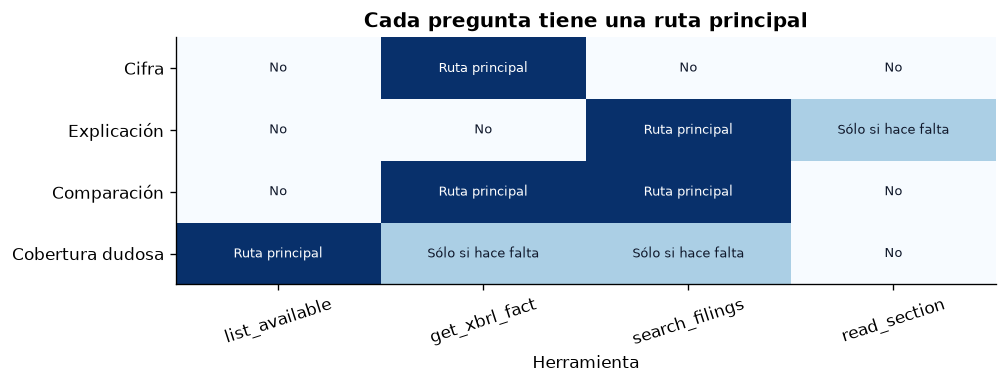

In [4]:
# Visual 2 · Qué herramienta encaja con cada pregunta
filas = ["Cifra", "Explicación", "Comparación", "Cobertura dudosa"]
columnas = ["list_available", "get_xbrl_fact", "search_filings", "read_section"]
matriz = np.array([[0, 3, 0, 0], [0, 0, 3, 1], [0, 3, 3, 0], [3, 1, 1, 0]])

fig, ax = plt.subplots(figsize=(8.5, 3.3))
imagen = ax.imshow(matriz, cmap="Blues", vmin=0, vmax=3, aspect="auto")
ax.set_xticks(range(4), columnas); ax.set_yticks(range(4), filas)
ax.tick_params(axis="x", rotation=18)
for i in range(4):
    for j in range(4):
        etiqueta = {0: "No", 1: "Sólo si hace falta", 3: "Ruta principal"}[matriz[i, j]]
        ax.text(j, i, etiqueta, ha="center", va="center",
                color="white" if matriz[i, j] == 3 else "#0F172A", fontsize=8)
ax.set_title("Cada pregunta tiene una ruta principal")
ax.set_xlabel("Herramienta")
plt.tight_layout(); plt.show()

**Qué nos dice esto:** cada tipo de pregunta tiene una ruta principal y una sola. Una comparación entre dos ejercicios es la única que necesita dos herramientas a la vez: la cifra de cada año y el texto que explica el cambio.

## 2. XBRL: cifras exactas y huecos honestos

**XBRL** es el formato en el que la empresa entrega sus cifras al regulador, cada una con su etiqueta. En vez de buscar un número dentro de un párrafo, se pide un concepto para una empresa y un ejercicio. Los tres ejemplos de abajo son los tres comportamientos que la herramienta tiene que dominar: una cifra que existe, un decimal que no se puede redondear y un dato que sencillamente no está.

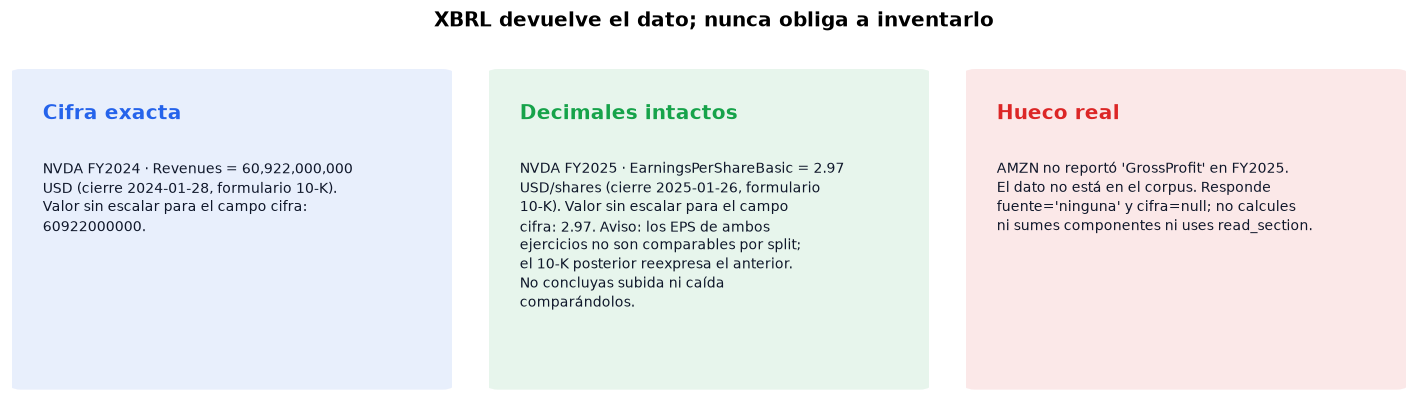

In [5]:
# Visual 3 · Tres comportamientos que debe dominar la herramienta
casos = [
    ("Cifra exacta", get_xbrl_fact.invoke({"ticker": "NVDA", "fiscal_year": 2024, "concept": "Revenues"}), AZUL),
    ("Decimales intactos", get_xbrl_fact.invoke({"ticker": "NVDA", "fiscal_year": 2025,
                                                  "concept": "EarningsPerShareBasic"}), VERDE),
    ("Hueco real", get_xbrl_fact.invoke({"ticker": "AMZN", "fiscal_year": 2025,
                                         "concept": "GrossProfit"}), ROJO),
]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, (titulo, resultado, color) in zip(axes, casos):
    ax.axis("off")
    ax.add_patch(FancyBboxPatch((.02, .04), .96, .9, boxstyle="round,pad=.03",
                                facecolor=color, edgecolor="none", alpha=.10))
    ax.text(.07, .82, titulo, transform=ax.transAxes, color=color, weight="bold", fontsize=12)
    ax.text(.07, .70, textwrap.fill(resultado, 42), transform=ax.transAxes,
            va="top", color="#0F172A", fontsize=8.5, linespacing=1.35)
fig.suptitle("XBRL devuelve el dato; nunca obliga a inventarlo", weight="bold")
plt.tight_layout(); plt.show()

**Qué nos dice esto:** XBRL da la cifra tal y como la reportó la empresa, sin redondear, y dice «no reportó» cuando el dato no existe. Ese aviso es lo que permite al agente abstenerse en vez de inventarse un número.

## 3. Búsqueda: encontrar la explicación

Para el texto se usa una consulta corta en inglés (el corpus está en inglés) y se filtra por empresa, ejercicio e item. Un **fragmento** es un trozo corto de una sección, con un identificador propio (`chunk_id`) que luego permite citar y verificar. La **similitud** mide cuánto se parece el fragmento al significado de la consulta: sirve para ordenar, no demuestra que el pasaje responda a la pregunta.

C:\Users\Usuario\Downloads\10k-financial-agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3260.05it/s]

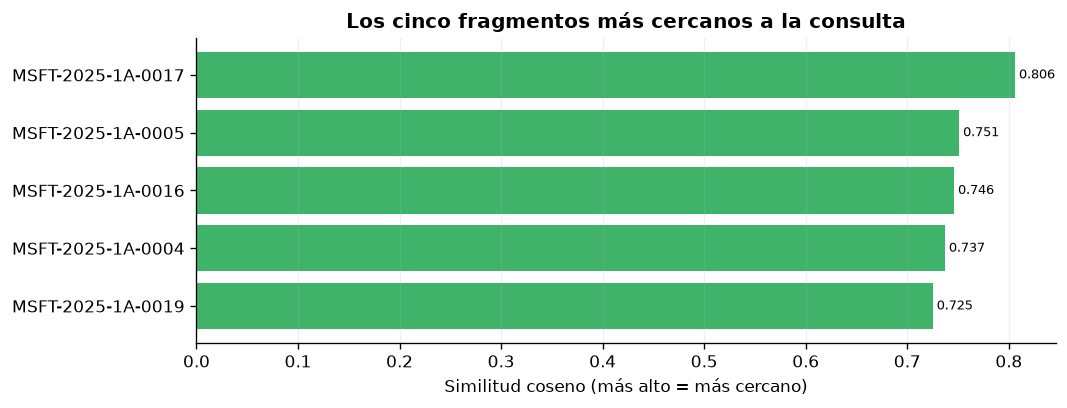

,chunk_id,similitud,vista_previa
0,MSFT-2025-1A-0017,0.806,"of operations. Issues in the development, depl..."
1,MSFT-2025-1A-0005,0.751,RISKS RELATING TO THE EVOLUTION OF OUR BUSINES...
2,MSFT-2025-1A-0016,0.746,Other digital safety abuses Our consumer servi...
3,MSFT-2025-1A-0004,0.737,"and sales incentives, which could adversely af..."
4,MSFT-2025-1A-0019,0.725,"to meet the evolving needs of our customers, p..."


In [6]:
# Una llamada real a la herramienta; mostramos el ranking, no cinco bloques de texto.
respuesta = search_filings.invoke({
    "query": "risks related to artificial intelligence products",
    "ticker": "MSFT", "fiscal_year": 2025, "item": "1A", "k": 5,
})
bloques = respuesta.split(chr(10) * 2 + "---" + chr(10) * 2)
filas_ranking = []
for bloque in bloques:
    cabecera, _, texto = bloque.partition(chr(10))
    hallado = re.search(r"\[([^\]]+)\].*similitud (-?[0-9]+[.][0-9]+)", cabecera)
    if hallado:
        filas_ranking.append({"chunk_id": hallado.group(1), "similitud": float(hallado.group(2)),
                              "vista_previa": textwrap.shorten(" ".join(texto.split()), 120)})
ranking = pd.DataFrame(filas_ranking)
if ranking.empty:
    raise RuntimeError(respuesta)

# Visual 4 · Ranking denso
fig, ax = plt.subplots(figsize=(9, 3.5))
orden = ranking.sort_values("similitud")
ax.barh(orden["chunk_id"], orden["similitud"], color=VERDE, alpha=.82)
ax.set_title("Los cinco fragmentos más cercanos a la consulta")
ax.set_xlabel("Similitud coseno (más alto = más cercano)")
ax.grid(axis="x", alpha=.2)
for y, valor in enumerate(orden["similitud"]):
    ax.text(valor, y, f" {valor:.3f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()
display(ranking[["chunk_id", "similitud", "vista_previa"]])

**Qué nos dice esto:** la búsqueda devuelve una lista ordenada de candidatos, no una respuesta. Las similitudes son parecidas entre sí, así que el primer resultado no siempre es el bueno: por eso el retrieval se medirá aparte, en el cuaderno 05.

## 4. Leer una sección completa cuesta mucho más

`read_section` devuelve el texto de una sección: conserva el contexto y puede añadir decenas de miles de tokens. Por eso ahora viene paginada (6.000 caracteres por llamada, ampliables con `max_chars`), para que una sola lectura no se coma el presupuesto. Un **token** es un trocito de texto, algo menos que una palabra. Como el agente reenvía todo lo que ha leído en cada vuelta, ese coste se vuelve a pagar una y otra vez.

**Cabecera devuelta:** `[AAPL FY2024 Item 7A · Quantitative and Qualitative Disclosures About Market Risk · 612 tokens]`

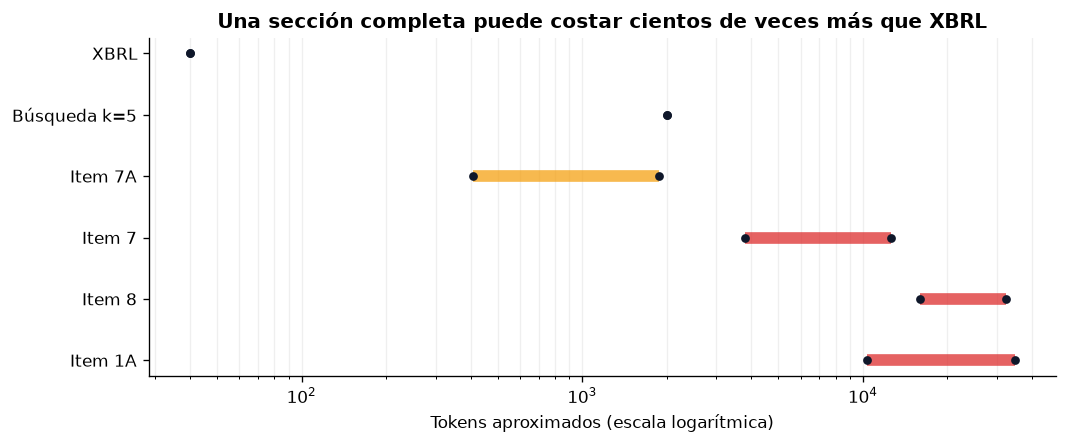

*XBRL y búsqueda son aproximaciones del enunciado; los rangos de secciones salen del corpus local.*

In [7]:
# Comprobación real sin volcar el texto completo
seccion_completa = read_section.invoke({"ticker": "AAPL", "fiscal_year": 2024, "item": "7A"})
display(Markdown(f"**Cabecera devuelta:** `{seccion_completa.splitlines()[0]}`"))

# Visual 5 · Coste relativo con rangos reales del corpus
secciones = datos.cargar_secciones()
rangos = secciones.groupby("item")["n_tokens"].agg(["min", "max"])
etiquetas = ["XBRL", "Búsqueda k=5", "Item 7A", "Item 7", "Item 8", "Item 1A"]
mins = np.array([40, 2000, rangos.loc["7A", "min"], rangos.loc["7", "min"],
                 rangos.loc["8", "min"], rangos.loc["1A", "min"]], dtype=float)
maxs = np.array([40, 2000, rangos.loc["7A", "max"], rangos.loc["7", "max"],
                 rangos.loc["8", "max"], rangos.loc["1A", "max"]], dtype=float)
y = np.arange(len(etiquetas))
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hlines(y, mins, maxs, color=[AZUL, VERDE, NARANJA, ROJO, ROJO, ROJO], linewidth=7, alpha=.72)
ax.scatter(mins, y, color="#0F172A", s=18, zorder=3); ax.scatter(maxs, y, color="#0F172A", s=18, zorder=3)
ax.set_xscale("log"); ax.set_yticks(y, etiquetas); ax.invert_yaxis()
ax.set_xlabel("Tokens aproximados (escala logarítmica)")
ax.set_title("Una sección completa puede costar cientos de veces más que XBRL")
ax.grid(axis="x", alpha=.2, which="both")
plt.tight_layout(); plt.show()
display(Markdown("*XBRL y búsqueda son aproximaciones del enunciado; los rangos de secciones salen del corpus local.*"))

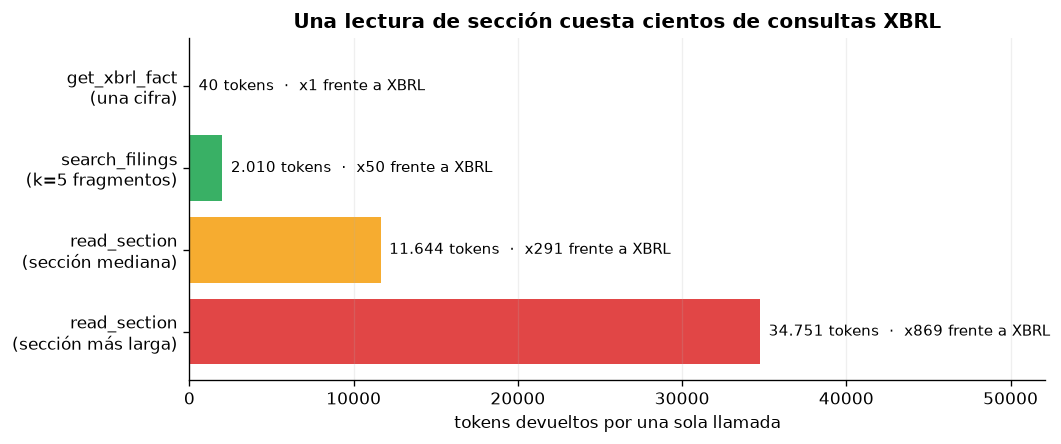

In [8]:
# Coste de UNA llamada, medido en tokens devueltos.
# XBRL y búsqueda son las referencias del enunciado (≈40 y ≈2.010 tokens);
# los dos valores de read_section salen de las 48 secciones del corpus local.
COSTE_TOKENS = {
    "get_xbrl_fact\n(una cifra)": 40.0,
    "search_filings\n(k=5 fragmentos)": 2010.0,
    "read_section\n(sección mediana)": float(secciones["n_tokens"].median()),
    "read_section\n(sección más larga)": float(secciones["n_tokens"].max()),
}

nombres = list(COSTE_TOKENS)
valores = [COSTE_TOKENS[n] for n in nombres]

fig, ax = plt.subplots(figsize=(9, 3.8))
barras = ax.barh(nombres, valores, color=[AZUL, VERDE, NARANJA, ROJO], alpha=.85)
ax.invert_yaxis()
for barra, valor in zip(barras, valores):
    etiqueta = f"{valor:,.0f} tokens  ·  x{valor / 40:,.0f} frente a XBRL".replace(",", ".")
    ax.text(valor + max(valores) * .015, barra.get_y() + barra.get_height() / 2,
            etiqueta, va="center", fontsize=9)
ax.set_xlim(0, max(valores) * 1.5)
ax.set_xlabel("tokens devueltos por una sola llamada")
ax.set_title("Una lectura de sección cuesta cientos de consultas XBRL")
ax.grid(axis="x", alpha=.2)
plt.tight_layout(); plt.show()

**Qué nos dice esto:** una consulta a XBRL devuelve unas decenas de tokens y una lectura de sección puede devolver decenas de miles. Con el mismo presupuesto se hacen cientos de consultas exactas o una sola lectura completa, así que `read_section` solo se justifica cuando la búsqueda no encuentra el pasaje.

## 5. Pruebas sin LLM

Los contratos, los huecos, los decimales y el ranking se verifican con la batería de pruebas local, sin gastar API. Verde significa que todo lo previsto terminó bien; rojo detiene el cuaderno y muestra el motivo.

C:\Users\Usuario\Downloads\10k-financial-agent\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 27 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


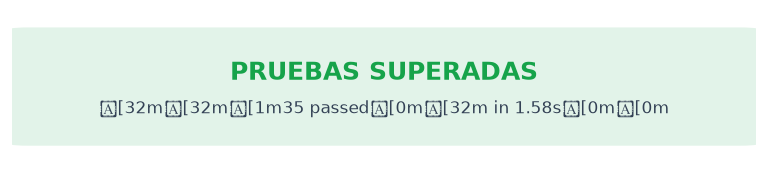

In [9]:
prueba = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_contratos.py", "tests/test_datos.py",
     "tests/test_herramientas.py", "tests/test_retrieval.py", "-q", "-p", "no:cacheprovider"],
    cwd=RAIZ, capture_output=True, text=True,
)

# Visual 6 · Estado de las pruebas
fig, ax = plt.subplots(figsize=(8, 1.6)); ax.axis("off")
color = VERDE if prueba.returncode == 0 else ROJO
estado = "PRUEBAS SUPERADAS" if prueba.returncode == 0 else "HAY PRUEBAS QUE REVISAR"
ultima = next((l for l in reversed(prueba.stdout.splitlines()) if "passed" in l or "failed" in l), "Sin resumen")
ax.add_patch(FancyBboxPatch((.02, .12), .96, .74, boxstyle="round,pad=.03",
                            facecolor=color, edgecolor="none", alpha=.12))
ax.text(.5, .58, estado, ha="center", va="center", color=color, weight="bold", fontsize=15)
ax.text(.5, .34, ultima, ha="center", va="center", color="#334155")
plt.show()
if prueba.returncode != 0:
    print(chr(10).join((prueba.stdout + prueba.stderr).splitlines()[-20:]))
    raise RuntimeError("La suite de pruebas no ha terminado correctamente")

**Qué nos dice esto:** el comportamiento de las cuatro herramientas está fijado por pruebas automáticas. Cualquier cambio posterior que las rompa se detecta antes de gastar una sola llamada al modelo.

## Idea final

- **Números:** `get_xbrl_fact`, incluso cuando el dato falta.
- **Texto y causas:** `search_filings`, siempre con su `chunk_id` para poder citar.
- **Dudas de cobertura:** `list_available`.
- **Sección completa:** `read_section`, solo como último recurso.

El siguiente paso es dar estas cuatro herramientas al agente y ver si sabe elegir: [02 · Agente baseline](02_agente_baseline.ipynb).